In [51]:
import pandas as pd
from category_encoders import TargetEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import seaborn as sns
import matplotlib.pyplot as plt

#### Load cleaned datasets

In [52]:
train_df = pd.read_csv("/Users/ashutosh/PycharmProjects/Housing_Prices_Regression_ML_End_to_End/data/processed/cleaning_train.csv")
eval_df = pd.read_csv("/Users/ashutosh/PycharmProjects/Housing_Prices_Regression_ML_End_to_End/data/processed/cleaning_eval.csv")
test_df = pd.read_csv("/Users/ashutosh/PycharmProjects/Housing_Prices_Regression_ML_End_to_End/data/processed/cleaning_test.csv")

pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows

print("Train date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Eval date range:", eval_df["date"].min(), "to", eval_df["date"].max())
print("Holdout date range:", test_df["date"].min(), "to", test_df["date"].max())

Train date range: 2012-03-31 to 2019-12-31
Eval date range: 2020-01-31 to 2021-12-31
Holdout date range: 2022-01-31 to 2023-12-31


#### Making sure of date-time

In [53]:
train_df["date"] = pd.to_datetime(train_df["date"])
eval_df["date"] = pd.to_datetime(eval_df["date"])
test_df["date"] = pd.to_datetime(test_df["date"])

In [54]:
train_df.head(2)

,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
0,2012-03-31,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,0.943662,0.142857,0.043478,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,Atlanta-Sandy Springs-Roswell,NaN,NaN
1,2012-03-31,200000.0,7500.0,104.931794,79.265873,1.0,1.0,1.0,2.0,290.0,0.909091,0.000000,0.000000,PGH,15469,2012,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,2441.0,41.8,20241.0,2385.0,1108.0,641.0,94600.0,1171.0,52.0,2376.0,2376.0,1018.0,105863.681174,Pittsburgh,NaN,NaN


#### Date characteristics

In [55]:
def add_date_features(df):
    df["year"] = df["date"].dt.year
    df["quarter"] = df["date"].dt.quarter
    df["month"] = df["date"].dt.month

    # Reorder columns
    df.insert(1, "year", df.pop("year"))
    df.insert(2, "quarter", df.pop("quarter"))
    df.insert(3, "month", df.pop("month"))
    return df

train_df = add_date_features(train_df)
eval_df = add_date_features(eval_df)
test_df = add_date_features(test_df)

In [56]:
print(train_df.shape)

(576815, 43)


In [57]:
train_df.head(2)

,date,year,quarter,month,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
0,2012-03-31,2012,1,3,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,0.943662,0.142857,0.043478,ATL,30002,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,Atlanta-Sandy Springs-Roswell,NaN,NaN
1,2012-03-31,2012,1,3,200000.0,7500.0,104.931794,79.265873,1.0,1.0,1.0,2.0,290.0,0.909091,0.000000,0.000000,PGH,15469,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,2441.0,41.8,20241.0,2385.0,1108.0,641.0,94600.0,1171.0,52.0,2376.0,2376.0,1018.0,105863.681174,Pittsburgh,NaN,NaN


In [58]:
print(eval_df.shape)

(148448, 43)


In [59]:
eval_df.head(2)

,date,year,quarter,month,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
0,2020-01-31,2020,1,1,184000.0,168450.0,123.333333,109.899800,35.0,30.0,34.0,37.0,50.0,0.954732,0.171429,0.300000,CHI,60482,3.0,0.0,2.0,0.0,68.0,30.0,60.0,5.0,14.0,10849.0,42.1,27037.0,10795.0,4598.0,964.0,169000.0,5690.0,414.0,10573.0,10573.0,5089.0,164839.734849,Chicago-Naperville-Elgin,NaN,NaN
1,2020-01-31,2020,1,1,140000.0,139000.0,94.691957,111.311054,61.0,81.0,83.0,54.0,10.0,0.963039,0.098361,0.469136,CIN,41071,35.0,5.0,4.0,3.0,139.0,259.0,86.0,1.0,8.0,20624.0,36.6,30324.0,19423.0,10164.0,802.0,132400.0,10479.0,552.0,19809.0,19809.0,9383.0,132164.314962,Cincinnati,NaN,NaN


In [60]:
print(test_df.shape)

(148943, 43)


In [61]:
test_df.head(2)

,date,year,quarter,month,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
0,2022-01-31,2022,1,1,340000.0,349999.0,189.867865,195.526649,282.0,287.0,241.0,73.0,12.0,0.991177,0.308511,0.634146,ORL,32771,9.0,0.0,1.0,1.0,56.0,64.0,18.0,4.0,9.0,57074.0,37.7,33896.0,56681.0,22246.0,1289.0,261800.0,29485.0,1469.0,55621.0,55621.0,24381.0,314667.746005,Orlando-Kissimmee-Sanford,NaN,NaN
1,2022-01-31,2022,1,1,310000.0,269900.0,243.839836,239.543726,49.0,47.0,43.0,7.0,6.5,1.006586,0.489796,0.723404,TPA,33778,21.0,0.0,3.0,2.0,35.0,57.0,32.0,0.0,22.0,15912.0,47.8,31277.0,15405.0,7865.0,1161.0,206600.0,7846.0,345.0,15423.0,15423.0,6733.0,325271.243813,Tampa-St. Petersburg-Clearwater,NaN,NaN


#### Rule of Thumb
1. Always fit encoders and transformers on the training set only
2. The resulting mappings that are learned in the step 1 are to be applied on the evaluation set then

#### Explanation
1. Because if we fit the encoders, transformers and scalers on both the sets (i.e. training and evaluation) then the evaluation set will specifically leak information into further downstream processes.
2. The metrics would look artificially good enough as the model would unknowingly take advantage by peeking into the data in future (i.e. evaluation set)

#### By avoiding the above given data leakage, evaluation set remains a true proxy of the unseen future data

#### The resulting model performance is real for when the model is deployed in the production

### Encoding the frequencies for Zipcodes

In [62]:
zip_counts = train_df["zipcode"].value_counts()

train_df["zipcode_freq"] = train_df["zipcode"].map(zip_counts)
eval_df["zipcode_freq"] = eval_df["zipcode"].map(zip_counts).fillna(0)
test_df["zipcode_freq"] = test_df["zipcode"].map(zip_counts).fillna(0)

print("Zip freq example (train):")
print(train_df[["zipcode", "zipcode_freq"]].head())


'''
Nuance:

- With the training set, we will build the dictionary in terms of frequency (zip_counts).
- With the evaluation sets, new counts will be never computed → it will only be looked up in the dictionary created earlier.
- If evaluation set has a previously unseen zipcode, it gets NaN, which will be replaced by 0.
'''

Zip freq example (train):
   zipcode  zipcode_freq
0    30002            94
1    15469            86
2    15464            85
3     2739            94
4    15461            94


'\nNuance:\n\n- With the training set, we will build the dictionary in terms of frequency (zip_counts).\n- With the evaluation sets, new counts will be never computed → it will only be looked up in the dictionary created earlier.\n- If evaluation set has a previously unseen zipcode, it gets NaN, which will be replaced by 0.\n'

#### Encoding of target 'city_full' column

In [63]:
te = TargetEncoder(cols=["city_full"])

train_df["city_encoded"] = te.fit_transform(train_df["city_full"], train_df["price"])
eval_df["city_encoded"] = te.transform(eval_df["city_full"])
test_df["city_encoded"] = te.transform(test_df["city_full"])

print("City encoding example (train):")
print(train_df[["city_full", "city_encoded"]].head())

'''
Nuance:

- On the training set, we apply fit_transform() function to compute the mappings from the city column to avg price column using training targets.
- On the evaluation set, we only apply transform() function which applies the training set's mapping and in turn it never looks at the evaluation set’s price column.
'''

City encoding example (train):
                       city_full   city_encoded
0  Atlanta-Sandy Springs-Roswell  192627.058387
1                     Pittsburgh  131828.753854
2                     Pittsburgh  131828.753854
3        Boston-Cambridge-Newton  472075.429542
4                     Pittsburgh  131828.753854


"\nNuance:\n\n- On the training set, we apply fit_transform() function to compute the mappings from the city column to avg price column using training targets.\n- On the evaluation set, we only apply transform() function which applies the training set's mapping and in turn it never looks at the evaluation set’s price column.\n"

#### Get rid of the unused and correlated/redundant columns

##### Leakage column 'median_sale_price' are dropped

In [64]:
drop_cols = ["date", "city_full", "city", "zipcode", "median_sale_price"]
train_df.drop(columns=drop_cols, inplace=True)
eval_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

In [65]:
print(train_df.shape)
train_df.head(5)

(576815, 40)


,year,quarter,month,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,lat,lng,zipcode_freq,city_encoded
0,2012,1,3,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,0.943662,0.142857,0.043478,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,NaN,NaN,94,192627.058387
1,2012,1,3,7500.0,104.931794,79.265873,1.0,1.0,1.0,2.0,290.0,0.909091,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,2441.0,41.8,20241.0,2385.0,1108.0,641.0,94600.0,1171.0,52.0,2376.0,2376.0,1018.0,105863.681174,NaN,NaN,86,131828.753854
2,2012,1,3,198000.0,122.807018,124.060150,1.0,1.0,1.0,1.0,49.0,0.989899,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1515.0,45.1,18623.0,1508.0,692.0,484.0,79300.0,711.0,61.0,1489.0,1489.0,641.0,126572.277873,NaN,NaN,85,131828.753854
3,2012,1,3,349900.0,171.817343,242.367722,13.0,18.0,30.0,54.0,126.0,0.901457,0.153846,0.277778,0.0,0.0,0.0,0.0,10.0,0.0,14.0,0.0,0.0,6073.0,47.4,39312.0,6055.0,3324.0,1142.0,419600.0,3207.0,147.0,5982.0,5982.0,2794.0,352711.838012,NaN,NaN,94,472075.429542
4,2012,1,3,66950.0,68.638393,32.495345,7.0,7.0,6.0,19.0,111.0,0.887859,0.142857,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,5.0,0.0,0.0,4191.0,42.1,19105.0,4158.0,2033.0,501.0,72100.0,1706.0,175.0,4037.0,4037.0,1489.0,70415.266483,NaN,NaN,94,131828.753854


In [66]:
print(eval_df.shape)
eval_df.head(5)

(148448, 40)


,year,quarter,month,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,lat,lng,zipcode_freq,city_encoded
0,2020,1,1,168450.0,123.333333,109.899800,35.0,30.0,34.0,37.0,50.0,0.954732,0.171429,0.300000,3.0,0.0,2.0,0.0,68.0,30.0,60.0,5.0,14.0,10849.0,42.1,27037.0,10795.0,4598.0,964.0,169000.0,5690.0,414.0,10573.0,10573.0,5089.0,1.648397e+05,NaN,NaN,94.0,221986.823469
1,2020,1,1,139000.0,94.691957,111.311054,61.0,81.0,83.0,54.0,10.0,0.963039,0.098361,0.469136,35.0,5.0,4.0,3.0,139.0,259.0,86.0,1.0,8.0,20624.0,36.6,30324.0,19423.0,10164.0,802.0,132400.0,10479.0,552.0,19809.0,19809.0,9383.0,1.321643e+05,NaN,NaN,94.0,150644.162953
2,2020,1,1,1600000.0,1386.111111,1801.309410,134.0,151.0,210.0,563.0,188.0,0.971567,0.037313,0.006623,344.0,11.0,26.0,8.0,404.0,2054.0,324.0,114.0,172.0,62541.0,43.3,126937.0,60995.0,41353.0,2346.0,1218900.0,37308.0,1440.0,60206.0,60206.0,31554.0,1.494755e+06,NaN,NaN,94.0,531812.641036
3,2020,1,1,550000.0,233.574442,243.803182,21.0,16.0,15.0,34.0,97.0,0.963443,0.095238,0.062500,0.0,0.0,1.0,0.0,14.0,0.0,10.0,0.0,0.0,5132.0,50.2,53105.0,4987.0,2481.0,1279.0,483500.0,2400.0,104.0,5036.0,5036.0,1957.0,4.882322e+05,NaN,NaN,94.0,472075.429542
4,2020,1,1,219900.0,183.644102,191.074971,14.0,18.0,16.0,15.0,42.0,0.961928,0.285714,0.388889,13.0,0.0,1.0,4.0,88.0,26.0,78.0,4.0,9.0,5103.0,38.8,29393.0,5093.0,1848.0,956.0,178700.0,2682.0,197.0,4934.0,4934.0,2425.0,1.944681e+05,NaN,NaN,94.0,221986.823469


In [67]:
print(test_df.shape)
test_df.head(5)

(148943, 40)


,year,quarter,month,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,lat,lng,zipcode_freq,city_encoded
0,2022,1,1,349999.0,189.867865,195.526649,282.0,287.0,241.0,73.0,12.0,0.991177,0.308511,0.634146,9.0,0.0,1.0,1.0,56.0,64.0,18.0,4.0,9.0,57074.0,37.7,33896.0,56681.0,22246.0,1289.0,261800.0,29485.0,1469.0,55621.0,55621.0,24381.0,314667.746005,NaN,NaN,94.0,197548.590519
1,2022,1,1,269900.0,243.839836,239.543726,49.0,47.0,43.0,7.0,6.5,1.006586,0.489796,0.723404,21.0,0.0,3.0,2.0,35.0,57.0,32.0,0.0,22.0,15912.0,47.8,31277.0,15405.0,7865.0,1161.0,206600.0,7846.0,345.0,15423.0,15423.0,6733.0,325271.243813,NaN,NaN,94.0,191019.763520
2,2022,1,1,299450.0,175.320145,287.500000,4.0,3.0,6.0,2.0,33.0,0.975694,0.000000,0.666667,3.0,0.0,0.0,0.0,8.0,15.0,7.0,0.0,2.0,725.0,51.1,36407.0,725.0,477.0,1393.0,265000.0,268.0,12.0,714.0,714.0,250.0,278119.378304,NaN,NaN,94.0,253558.662156
3,2022,1,1,240000.0,164.262821,165.733497,3.0,0.0,2.0,1.0,3.0,1.029340,0.666667,0.666667,9.0,0.0,0.0,0.0,15.0,7.0,6.0,0.0,2.0,776.0,31.8,20361.0,767.0,286.0,982.0,145300.0,385.0,14.0,738.0,738.0,348.0,253267.647544,NaN,NaN,77.0,156494.508429
4,2022,1,1,290000.0,143.509798,147.023086,450.0,538.0,481.0,263.0,21.0,1.008350,0.455556,0.553903,19.0,2.0,5.0,3.0,26.0,69.0,39.0,0.0,8.0,90956.0,30.2,27373.0,89745.0,30306.0,1326.0,183800.0,46431.0,2515.0,86814.0,86814.0,39989.0,253160.479867,NaN,NaN,94.0,197197.805741


#### Saving the feature engineered sets

In [68]:
train_df.to_csv("/Users/ashutosh/PycharmProjects/Housing_Prices_Regression_ML_End_to_End/data/processed/feature_engineered_train.csv", index=False)
eval_df.to_csv("/Users/ashutosh/PycharmProjects/Housing_Prices_Regression_ML_End_to_End/data/processed/feature_engineered_eval.csv", index=False)
test_df.to_csv("/Users/ashutosh/PycharmProjects/Housing_Prices_Regression_ML_End_to_End/data/processed/feature_engineered_test.csv", index=False)

print("Feature engineering complete.")
print("Train shape:", train_df.shape)
print("Eval shape:", eval_df.shape)
print("Test shape:", test_df.shape)

Feature engineering complete.
Train shape: (576815, 40)
Eval shape: (148448, 40)
Test shape: (148943, 40)


1. Fit the frequency encoding to the training set only, apply that mappings to the evaluation set (with fillna(0) in case the evaluation set has any unseen zipcodes).

2. Fit the target encoding to the training set only, the apply them to the evaluation set.

3. Wrote a helper function 'add_date_features' so that the date feature's logic isn’t duplicated.

4. Removed the unused columns consistently from all the three datasets (i.e. training, evaluation, testing)

5. Removed the highly correlated column "median_sale_price" from all the three datasets (i.e. training, evaluation, testing)

6. The two separate outputs are saved seperately (i.e. feature_engineered_train.csv  &  feature_engineered_eval.csv)


Nuance:

1. Training → fit transformations (learn rules from the past).

2. Evaluation → transform with those rules/ mappings (apply them to future data).

3. Never re-fit on evaluation set. That’s what keeps the evaluation set “unseen” and leakage-free.

### Multicollinearity

##### To investigate about the multicollinearity we will use:
1. Variation Inflation Factor
2. Correlation matrix

In [69]:
df = train_df

In [70]:
def calculate_vif(df, target_col=None):
    """
    Compute the Variance Inflation Factor (VIF) for each numeric column in the df.
    """
    # Keep only numeric columns
    numeric_df = df.select_dtypes(include=['float64', 'int64']).copy()

    # Remove the target columns if provided
    if target_col and target_col in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=[target_col])

    # Add constant for statsmodels
    X = add_constant(numeric_df)

    # Compute VIF (skip the first column = constant)
    vif_data = pd.DataFrame()
    vif_data["feature"] = numeric_df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i + 1)  # skip constant at index 0
        for i in range(len(numeric_df.columns))
    ]

    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)


# Look at VIF and correlation with original training dataset
df = pd.read_csv("/Users/ashutosh/PycharmProjects/Housing_Prices_Regression_ML_End_to_End/data/raw/train.csv")
vif_table = calculate_vif(df, target_col="price")
print(vif_table)


/Users/ashutosh/PycharmProjects/Housing_Prices_Regression_ML_End_to_End/venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                         feature          VIF
0        Total School Enrollment          inf
1    Total School Age Population          inf
2               Total Population  6600.440350
3              Total Labor Force   839.557009
4            Median Commute Time   650.528668
5   Total Families Below Poverty   573.705680
6            Total Housing Units    21.298479
7                   new_listings    19.930888
8                     homes_sold    13.409262
9          Unemployed Population    12.881559
10                    restaurant    10.915101
11                          bank    10.680631
12                   supermarket     9.630326
13                 pending_sales     9.241440
14             Median Home Value     6.826955
15                     inventory     5.887100
16                          park     5.676253
17                        school     5.657422
18                       station     4.654858
19             Per Capita Income     4.619926
20                   Median Rent  

##### Interpretation
1. If Variance Inflation Factor > 10 (High Multicollinearity)
2. If Variance Inflation Factor > 100 (Extremely High Multicollinearity, remove or re-feature engineer columns right away)
3. If Variance Inflation Factor = ∞ (Extremely High Multicollinearity possible there is, perfect linear redundancy, remove column right away)

In [71]:
offenders = ["Total Population", "Total Labor Force", "Total Families Below Poverty"]
corr_matrix = df[offenders].corr()
corr_matrix

,Total Population,Total Labor Force,Total Families Below Poverty
Total Population,1.000000,0.985715,0.998992
Total Labor Force,0.985715,1.000000,0.985703
Total Families Below Poverty,0.998992,0.985703,1.000000


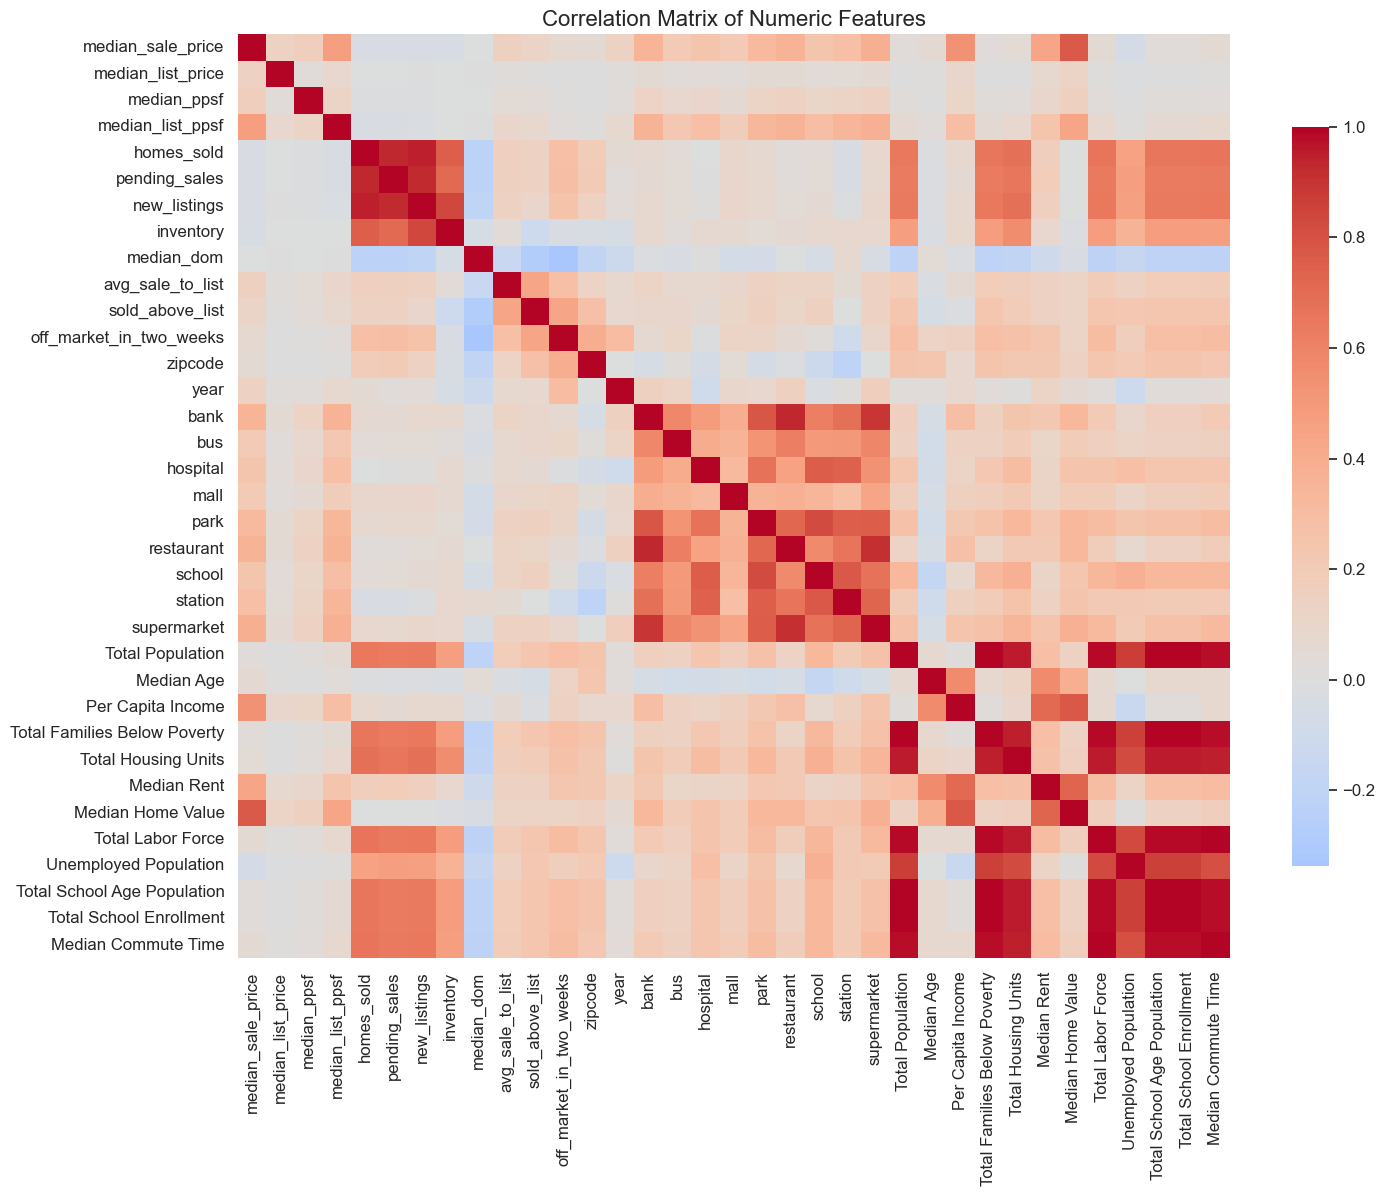

In [72]:
# Select only numeric features (exclude the target 'price')
numeric_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=["price"], errors="ignore")

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Display full matrix as heatmap
plt.figure(figsize=(16,12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,   # set to True if you want numbers on cells
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Numeric Features", fontsize=16)
plt.show()

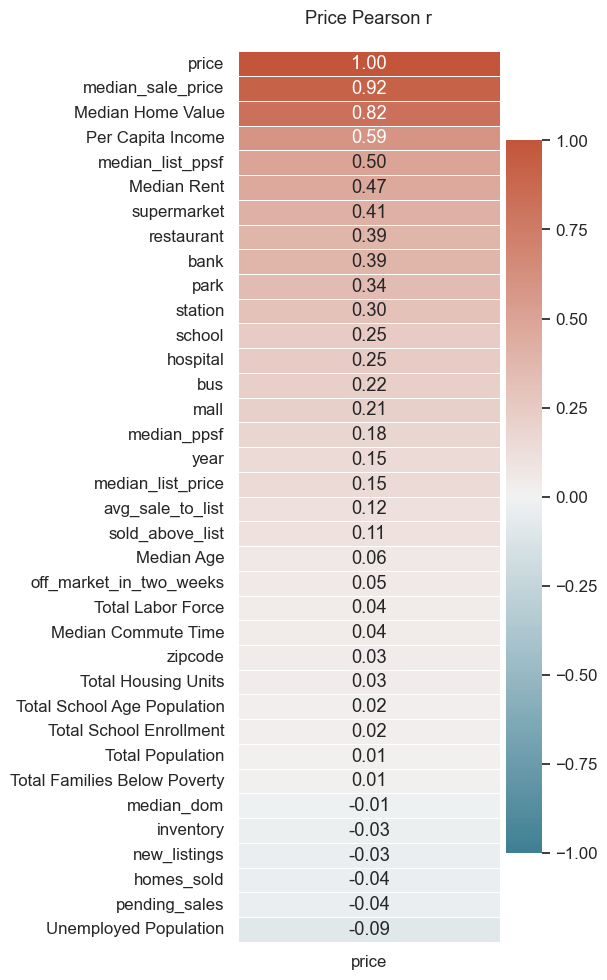

In [73]:
# Compute correlations with price
num_cols = df.select_dtypes("number").columns
corr_vec  = df[num_cols].corr(method="pearson")["price"].sort_values(ascending=False)
sns.set_theme(style="white")
sns.set(font_scale=1.1)
plt.figure(figsize=(6,10))
ax = sns.heatmap(
        corr_vec.to_frame(),
        annot=True, fmt=".2f",
        vmin=-1, vmax=1,
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        center=0,
        linewidths=.5, linecolor="white",
        cbar_kws={"shrink":0.8, "pad":0.02}
     )
ax.set_title("Price Pearson r", pad=20)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()